In [2]:
import sympy as sp
x, y, s, t, phi, a, b = sp.symbols('x y s t phi a b', real=True)
pi, oo = sp.pi, sp.oo
Rational = sp.Rational
sin, cos, exp, log, sqrt = sp.sin, sp.cos, sp.exp, sp.log, sp.sqrt
integrate, Eq, solve, simplify = sp.integrate, sp.Eq, sp.solve, sp.simplify
sp.init_printing(use_unicode=True)

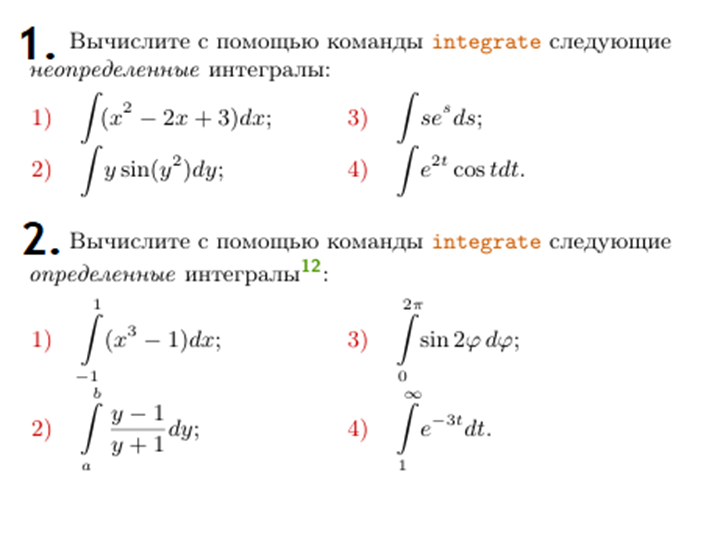

In [3]:
#1
I1 = integrate(x**2 - 2*x + 3, x)
I2 = integrate(y*sin(y**2), y)
I3 = integrate(s*exp(s), s)
I4 = integrate(exp(2*t)*cos(t), t)

print("1) Неопределённые интегралы:")
sp.pprint(I1); print()
sp.pprint(I2); print()
sp.pprint(I3); print()
sp.pprint(I4); print()

#2
D1 = integrate(x**3 - 1, (x, -1, 1))
D2 = integrate((y - 1)/(y + 1), (y, a, b))
D3 = integrate(sin(2*phi), (phi, 0, 2*pi))
D4 = integrate(exp(-3*t), (t, 1, oo))

print("2) Определённые интегралы:")
sp.pprint(D1); print()
sp.pprint(D2); print()
sp.pprint(D3); print()
sp.pprint(D4); print()

1) Неопределённые интегралы:
 3           
x     2      
── - x  + 3⋅x
3            

    ⎛ 2⎞ 
-cos⎝y ⎠ 
─────────
    2    

         s
(s - 1)⋅ℯ 

 2⋅t             2⋅t       
ℯ   ⋅sin(t)   2⋅ℯ   ⋅cos(t)
─────────── + ─────────────
     5              5      

2) Определённые интегралы:
-2

-a + b + 2⋅log(a + 1) - 2⋅log(b + 1)

0

 -3
ℯ  
───
 3 



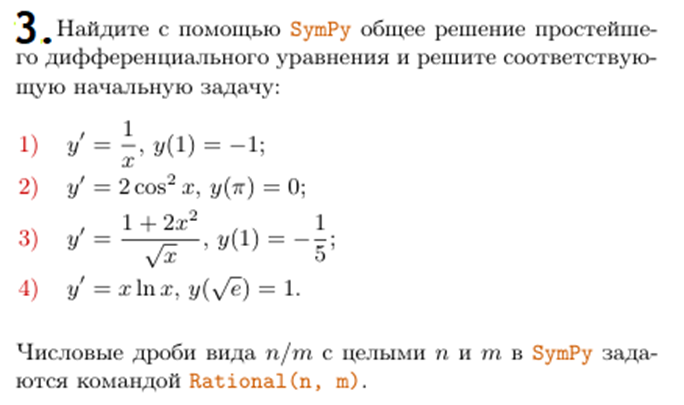

In [4]:
#3
#метод: y = ∫f(x)dx + C, затем находим C по начальному условию
C = sp.symbols('C')

def solve_ivp_rhs(rhs, var, x0, y0):
    y_general = integrate(rhs, var) + C
    C_val = solve(Eq(y_general.subs(var, x0), y0), C)[0]
    return simplify(y_general.subs(C, C_val))

# 3.1) y' = 1/x, y(1) = -1
y1 = solve_ivp_rhs(1/x, x, 1, -1)

# 3.2) y' = 2 cos^2 x, y(pi) = 0
y2 = solve_ivp_rhs(2*cos(x)**2, x, pi, 0)

# 3.3) y' = (1 + 2 x^2)/sqrt(x), y(1) = -1/5
y3 = solve_ivp_rhs((1 + 2*x**2)/sqrt(x), x, 1, Rational(-1, 5))

# 3.4) y' = x ln x, y(sqrt(e)) = 1
y4 = solve_ivp_rhs(x*log(x), x, sqrt(exp(1)), 1)

print("3) Решения НЗ:")
print("y(x) для 1):"); sp.pprint(y1); print()
print("y(x) для 2):"); sp.pprint(y2); print()
print("y(x) для 3):"); sp.pprint(y3); print()
print("y(x) для 4):"); sp.pprint(y4); print()

3) Решения НЗ:
y(x) для 1):
log(x) - 1

y(x) для 2):
    sin(2⋅x)    
x + ──────── - π
       2        

y(x) для 3):
   5/2           
4⋅x              
────── + 2⋅√x - 3
  5              

y(x) для 4):
 2           2    
x ⋅log(x)   x     
───────── - ── + 1
    2       4     

